In [ ]:
# Customer Churn Prediction Using Logistic Regression from Scratch

## Project Objective

#The objective of this project is to develop a Logistic Regression classifier from scratch using only NumPy to predict customer churn in a telecommunications company. The project includes complete data preprocessing, exploratory data analysis, feature engineering, implementation of Logistic Regression using Gradient Descent, performance evaluation, and comparison with Scikit-learn's Logistic Regression model.

In [ ]:
## Problem Statement

#Customer churn is one of the major challenges faced by subscription-based businesses. Predicting whether a customer is likely to leave helps companies take preventive measures and improve customer retention.

#In this project, we build a binary classification model that predicts whether a customer will churn based on demographic information, account details, and subscribed services.

#Unlike traditional machine learning projects that rely entirely on library implementations, this project develops Logistic Regression from scratch using NumPy to understand the underlying mathematical concepts and optimization process.

In [ ]:
## Workflow

# 1. Import Libraries
# 2. Load Dataset
# 3. Exploratory Data Analysis
# 4. Data Cleaning
# 5. Feature Engineering
# 6. Data Preprocessing
# 7. Train-Test Split
# 8. Mathematical Foundation of Logistic Regression
# 9. Logistic Regression from Scratch
# 10. Model Evaluation
# 11. Class Imbalance Handling
# 12. Comparison with Scikit-learn
# 13. Conclusion

In [ ]:
# Numerical Computation
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# Benchmark Model
from sklearn.linear_model import LogisticRegression

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

sns.set(font_scale=1.0)

np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CustomerChurnPrediction/Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset Shape
Number of Rows    : 7043
Number of Columns : 21


In [ ]:
print("=" * 50)
print("Column Names")
print("=" * 50)

df.columns.tolist()

Column Names


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
print("=" * 50)
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [ ]:
df.describe().T  # statistical summary

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# 4. Exploratory Data Analysis (EDA)

# Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify patterns, detect anomalies, study feature distributions, and explore the relationships between variables.

# Understanding the data before preprocessing helps in making informed decisions during feature engineering and model building.

In [ ]:
## 4.1 Target Variable Analysis

# The target variable in this project is **Churn**, which indicates whether a customer has left the company's services.

# Before building a classification model, it is important to examine:

# - Class distribution
# - Percentage of churned customers
# - Whether the dataset is balanced or imbalanced

In [ ]:
print("="*50)
print("Target Variable Distribution")
print("="*50)

print(df["Churn"].value_counts())

Target Variable Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


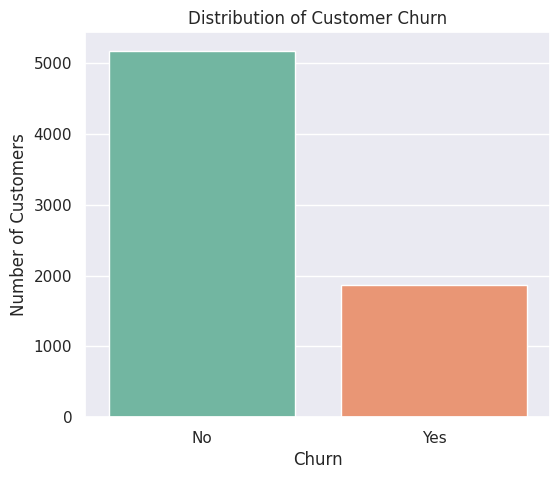

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

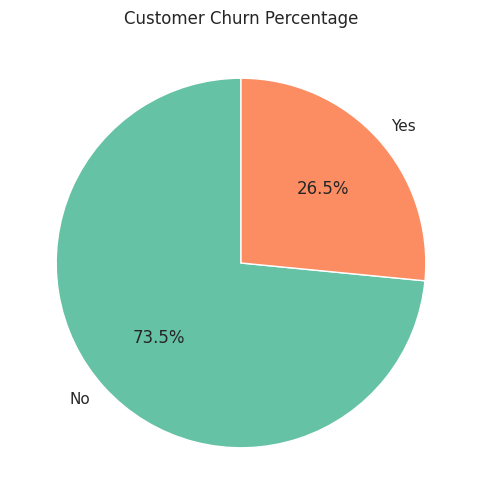

In [ ]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66c2a5", "#fc8d62"]
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.show()

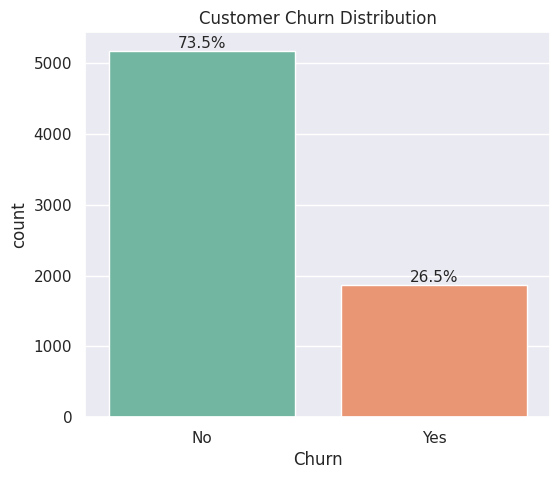

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

total = len(df)

for p in ax.patches:

    percentage = 100 * p.get_height() / total

    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Customer Churn Distribution")

plt.show()

In [ ]:
summary = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": (df["Churn"].value_counts(normalize=True)*100).round(2)
})

summary

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [ ]:
### Interpretation

# - The dataset contains both churned and non-churned customers.
# - Approximately **73%** of customers did not churn, while around **27%** churned.
# - The dataset is moderately imbalanced, with the majority class being non-churn customers.
# - Since class imbalance exists, relying solely on accuracy may be misleading.
# - Additional evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will therefore be used.

In [ ]:
## 4.2 Numerical Feature Analysis

# The numerical features provide important information about customer behavior and billing patterns.

# In this section, we analyze the distribution of numerical variables to understand:

# - The spread of values
# - Central tendency
# - Presence of skewness
# - Presence of outliers
# - Customer behavior patterns

# The numerical features analyzed are:

# - Tenure
# - Monthly Charges

In [ ]:
numerical_columns = ["tenure", "MonthlyCharges"]

print("Numerical Features:")
print(numerical_columns)

Numerical Features:
['tenure', 'MonthlyCharges']


In [ ]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


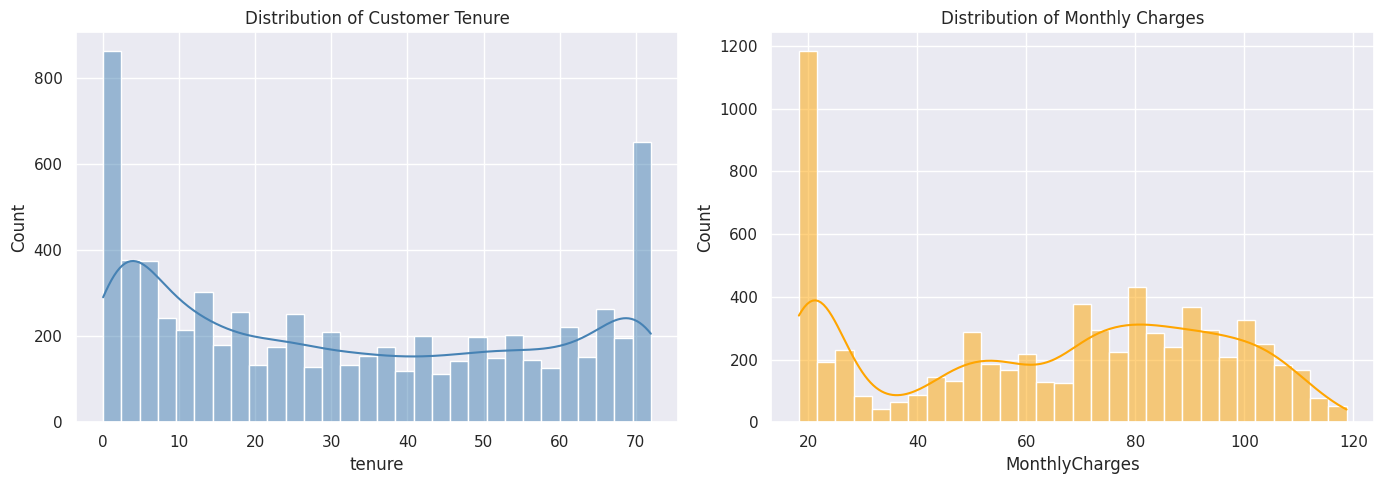

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Tenure
sns.histplot(
    df["tenure"],
    bins=30,
    kde=True,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Distribution of Customer Tenure")

# Monthly Charges
sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True,
    ax=axes[1],
    color="orange"
)

axes[1].set_title("Distribution of Monthly Charges")

plt.tight_layout()
plt.show()

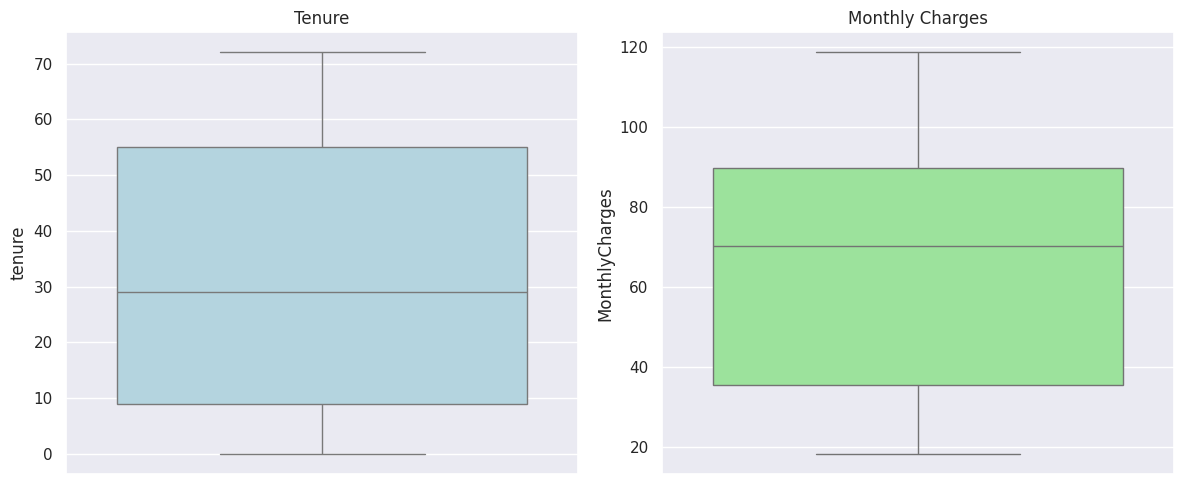

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(
    y=df["tenure"],
    ax=axes[0],
    color="lightblue"
)

axes[0].set_title("Tenure")

sns.boxplot(
    y=df["MonthlyCharges"],
    ax=axes[1],
    color="lightgreen"
)

axes[1].set_title("Monthly Charges")

plt.tight_layout()
plt.show()

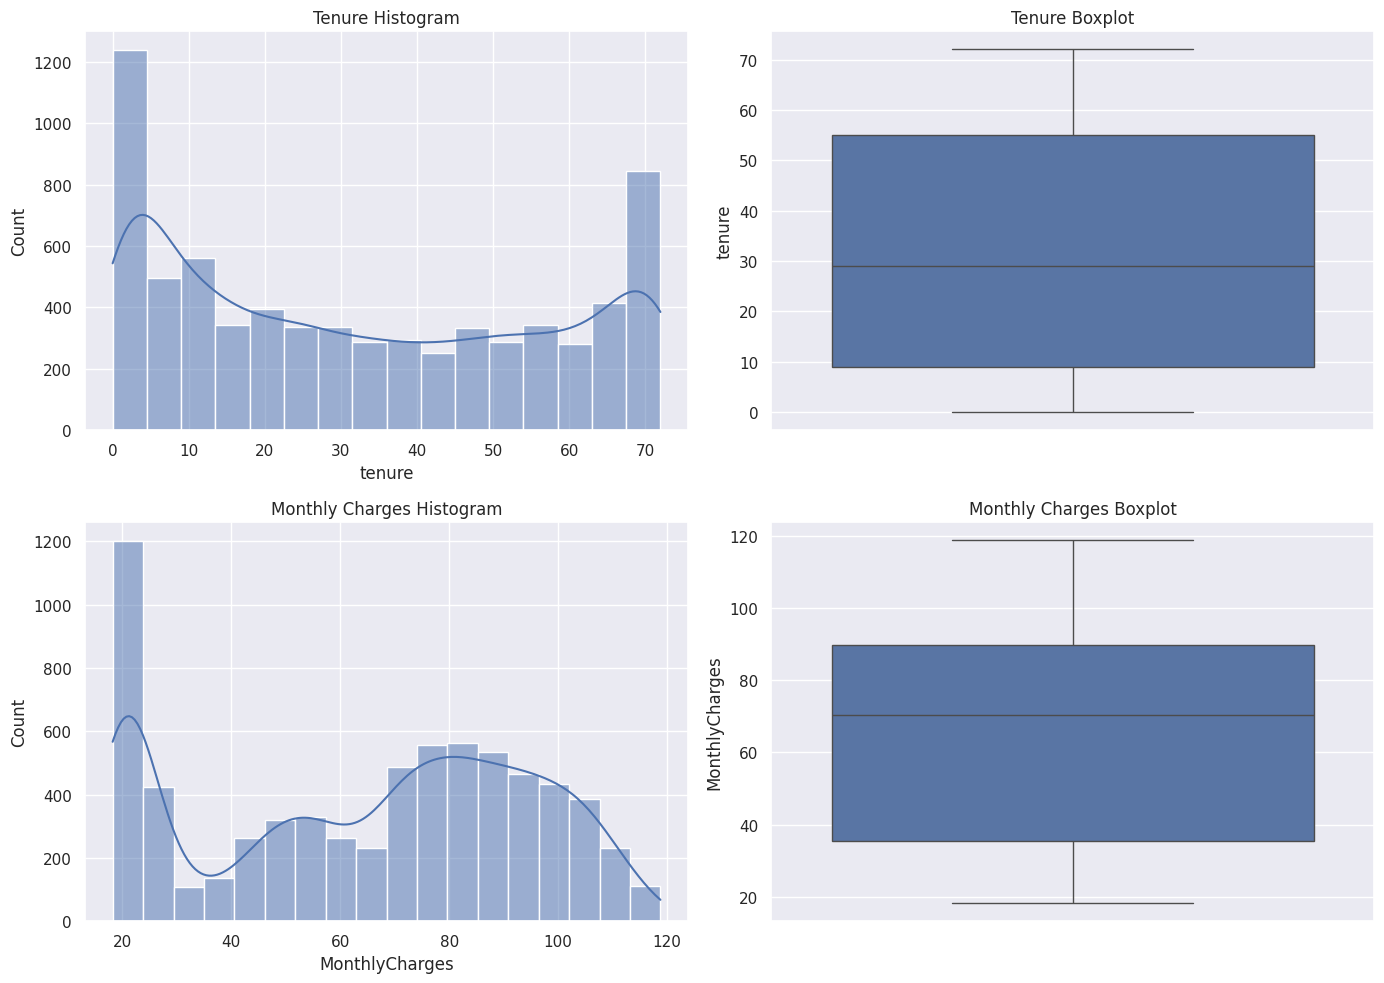

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.histplot(df["tenure"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Tenure Histogram")

sns.boxplot(y=df["tenure"], ax=axes[0,1])
axes[0,1].set_title("Tenure Boxplot")

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Monthly Charges Histogram")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1,1])
axes[1,1].set_title("Monthly Charges Boxplot")

plt.tight_layout()
plt.show()

In [ ]:
### Interpretation

#### 1. Customer Tenure

# - Customer tenure ranges from **0 to 72 months**, indicating that the dataset includes both newly joined and long-term customers.
# - The histogram shows a high concentration of customers with very low tenure (0–5 months), suggesting that many customers leave shortly after joining or that the company acquires many new customers.
# - Another noticeable concentration appears around **70–72 months**, indicating a large group of loyal, long-term customers.
# - The distribution is **not normally distributed** and appears **bimodal**, with peaks at the beginning and end of the tenure range.
# - The boxplot does not show any significant outliers, indicating that the tenure values fall within the expected business range.

# #### 2. Monthly Charges

# - Monthly charges range from approximately **$18 to $119**.
# - The distribution is **multimodal**, suggesting different pricing plans offered by the company.
# - A large number of customers pay around **$20**, while another major concentration is observed between **$70 and $100**.
# - The boxplot does not indicate extreme outliers.

# #### Overall Observation

# The numerical features do not exhibit significant outliers and appear suitable for further preprocessing. However, the distributions are not normal, which is common in real-world business datasets.

In [ ]:
## 4.3 Categorical Feature Analysis

# The majority of features in the IBM Telco Customer Churn dataset are categorical. These variables describe customer demographics, subscribed services, contract details, and billing preferences.

# Analyzing these features helps us understand customer characteristics and identify the most common categories before studying their relationship with churn.

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical Features:")
print(categorical_columns)

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
# Remove these columns
categorical_columns = [
    col for col in categorical_columns
    if col not in ["customerID", "TotalCharges", "Churn"]
]

print(categorical_columns)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
for col in categorical_columns:

    print("=" * 50)
    print(f"{col}")
    print("=" * 50)

    display(df[col].value_counts())

    print()

gender


,count
gender,
Male,3555
Female,3488



Partner


,count
Partner,
No,3641
Yes,3402



Dependents


...

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473



PaperlessBilling


,count
PaperlessBilling,
Yes,4171
No,2872



PaymentMethod


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


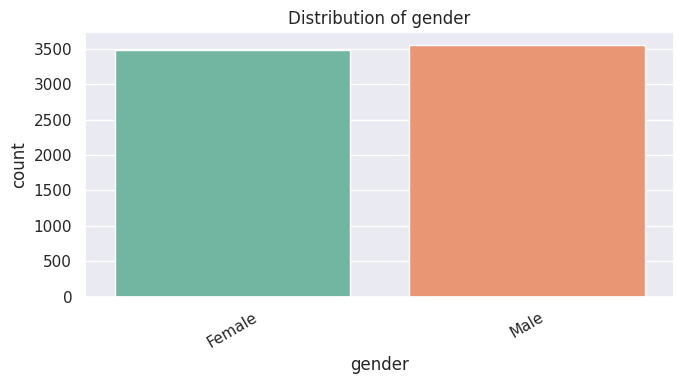

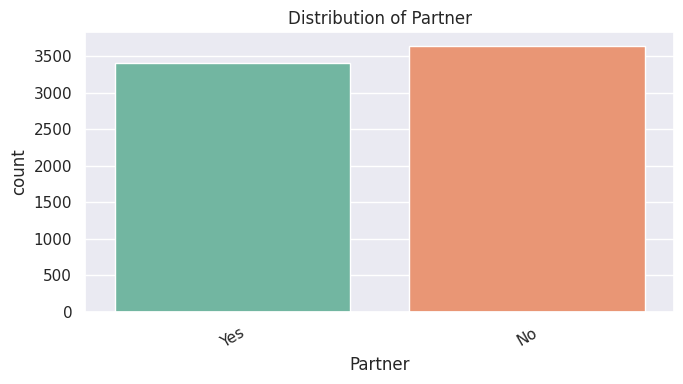

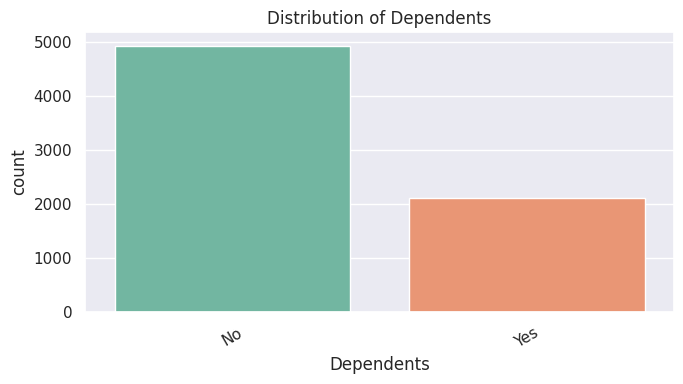

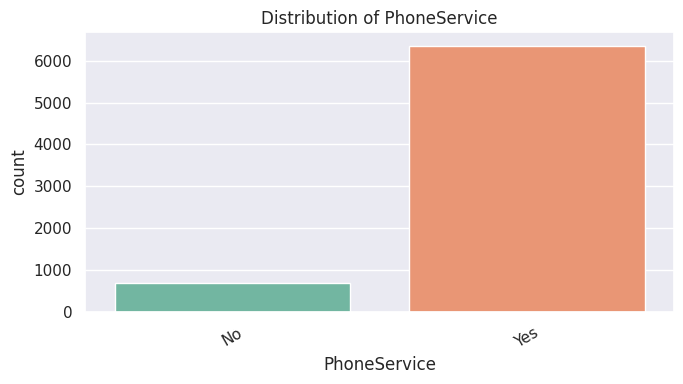

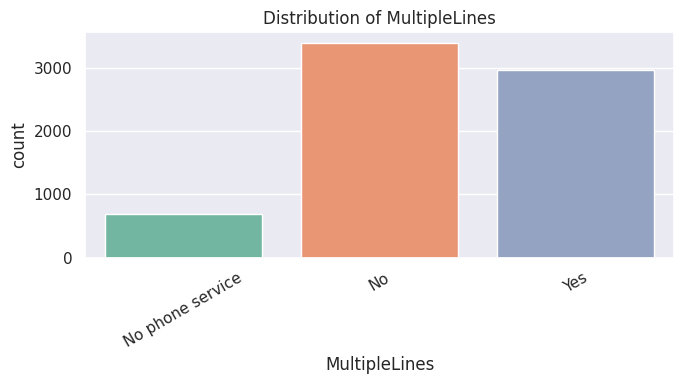

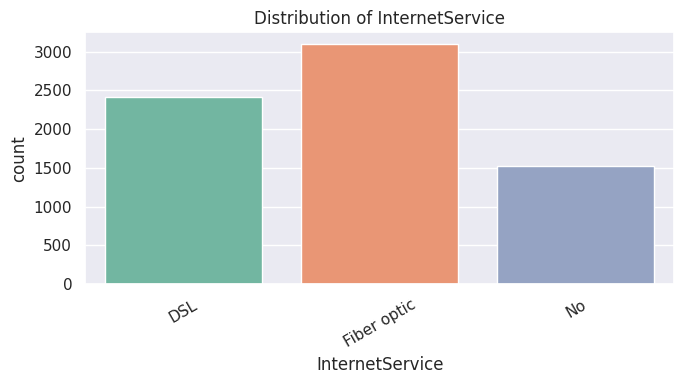

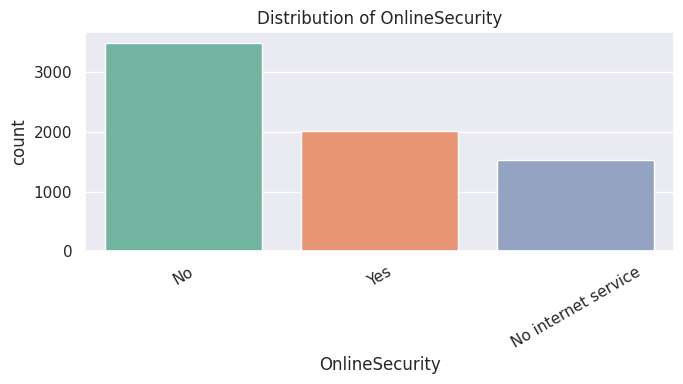

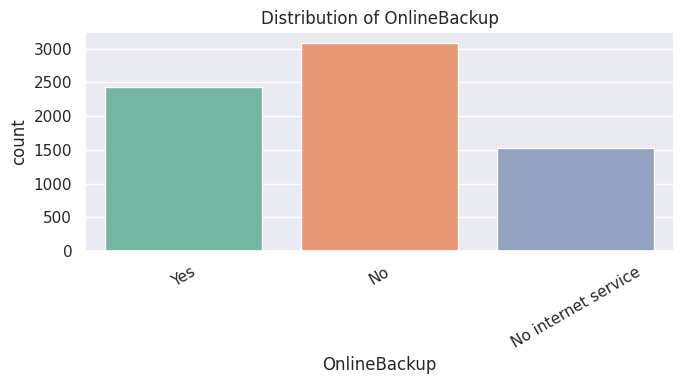

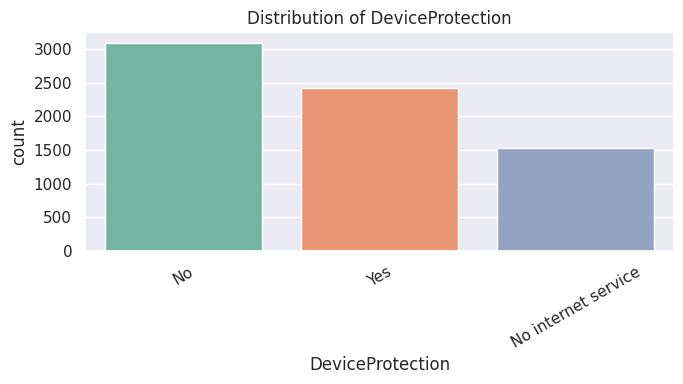

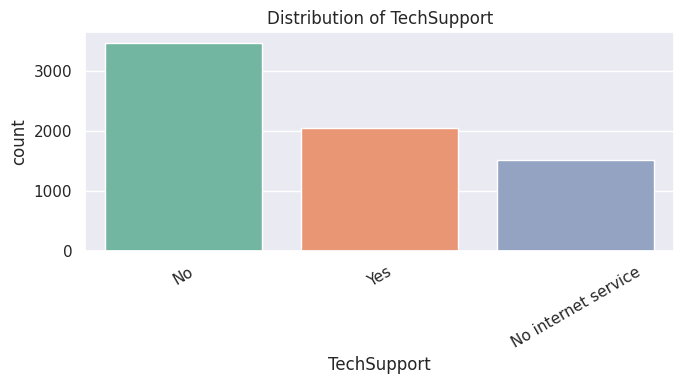

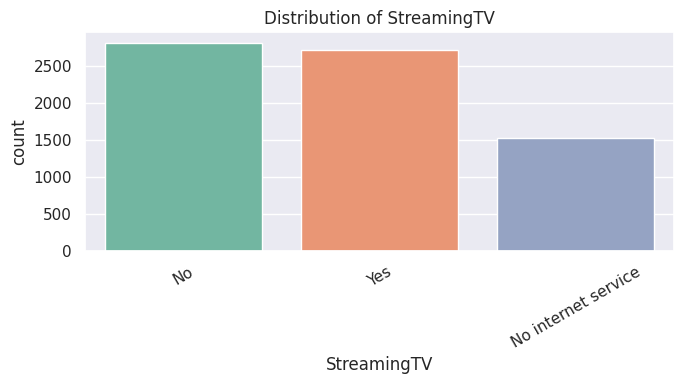

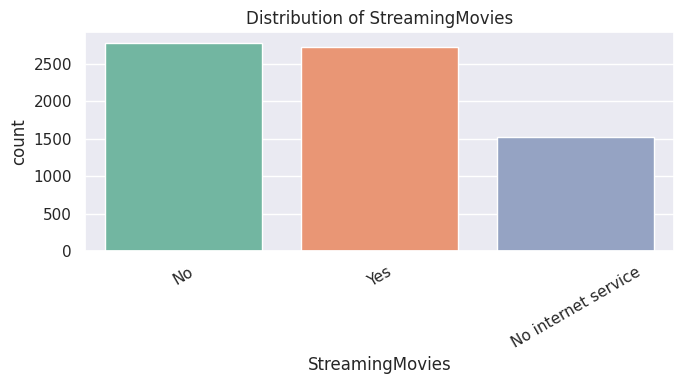

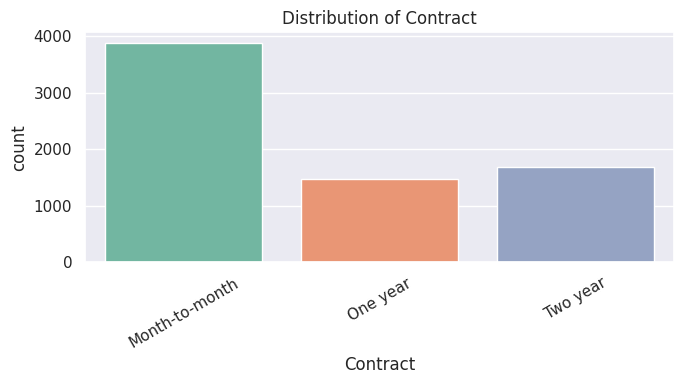

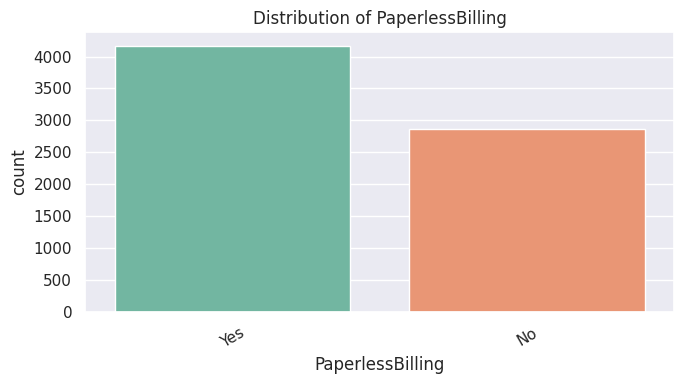

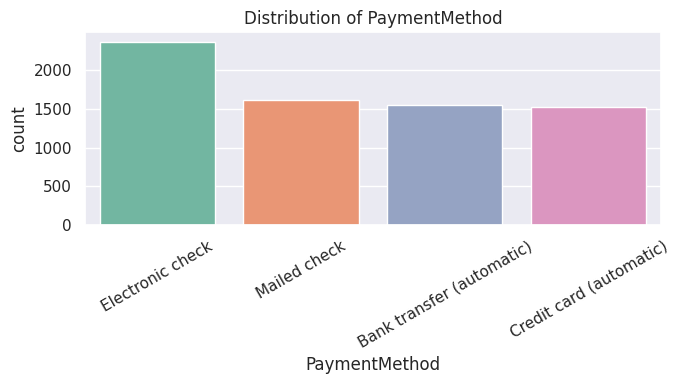

In [ ]:
for col in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        palette="Set2"
    )

    plt.title(f"Distribution of {col}")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

In [ ]:
for col in categorical_columns:

    print("="*60)

    print(f"{col}")

    print("="*60)

    percentage = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    display(percentage)

    print()

gender


,proportion
gender,
Male,50.48
Female,49.52



Partner


,proportion
Partner,
No,51.7
Yes,48.3



Dependents


...

,proportion
Contract,
Month-to-month,55.02
Two year,24.07
One year,20.91



PaperlessBilling


,proportion
PaperlessBilling,
Yes,59.22
No,40.78



PaymentMethod


,proportion
PaymentMethod,
Electronic check,33.58
Mailed check,22.89
Bank transfer (automatic),21.92
Credit card (automatic),21.61


In [ ]:
### Interpretation

# #### Customer Demographics
# - The dataset contains an almost equal number of male and female customers.
# - Slightly more customers do not have partners than those who do.
# - Most customers do not have dependents.

# #### Phone and Internet Services
# - Most customers subscribe to phone services.
# - Among internet users, Fiber Optic is the most common service, followed by DSL.
# - A smaller portion of customers do not use internet services.

# #### Additional Services
# - More customers do not subscribe to Online Security and Tech Support than those who do.
# - Online Backup and Device Protection have a relatively balanced distribution.
# - Streaming TV and Streaming Movies show nearly equal numbers of subscribers and non-subscribers.

# #### Account Information
# - Month-to-month contracts are the most common contract type.
# - Paperless billing is preferred by a majority of customers.
# - Electronic check is the most frequently used payment method.

# Overall, the categorical variables exhibit good variation, making them suitable predictors for customer churn.

In [ ]:
## 4.4 Numerical Features vs Churn

# In this section, we analyze how numerical features differ between customers who churned and those who remained with the company.

# This helps identify whether customer tenure and monthly charges influence churn behavior.

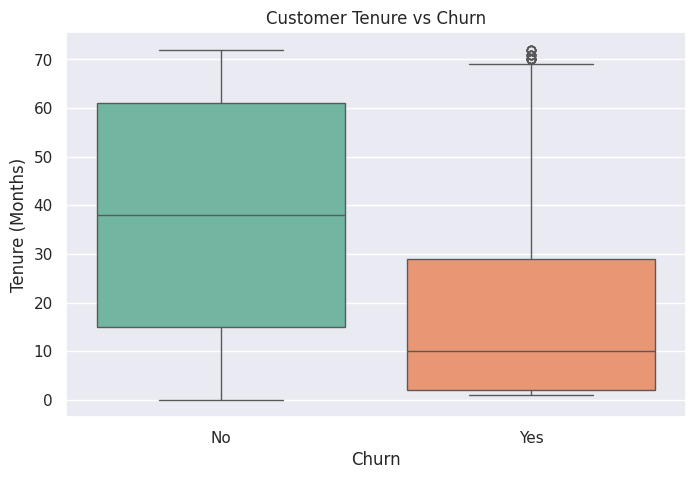

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Set2"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

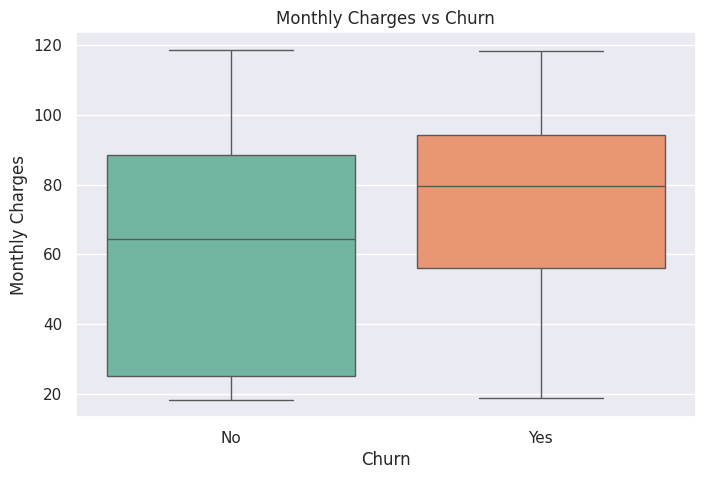

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [ ]:
## 4.5 Categorical Features vs Churn

# In this section, we investigate how different categorical features influence customer churn.

# Instead of simply counting customers, we analyze the **proportion of churn within each category**. This provides a clearer understanding of which customer characteristics are associated with higher or lower churn rates.

# The following features are analyzed:

# - Contract
# - Internet Service
# - Online Security
# - Tech Support
# - Payment Method
# - Paperless Billing
# - Partner

In [ ]:
important_features = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner"
]

Contract vs Churn


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


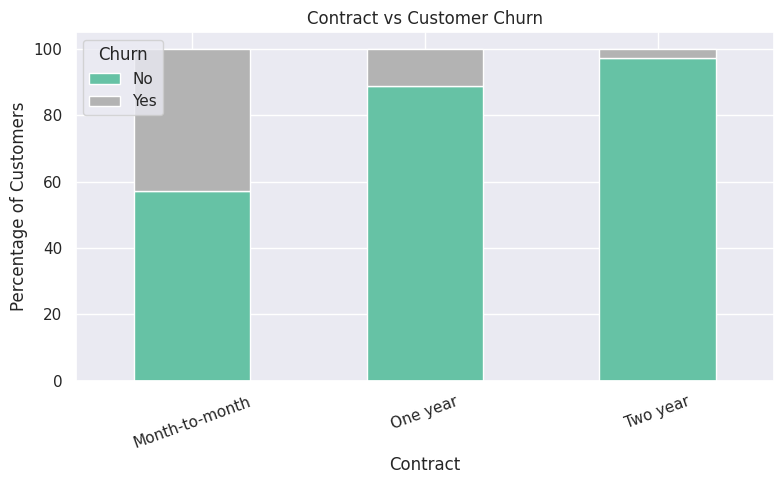

InternetService vs Churn


Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


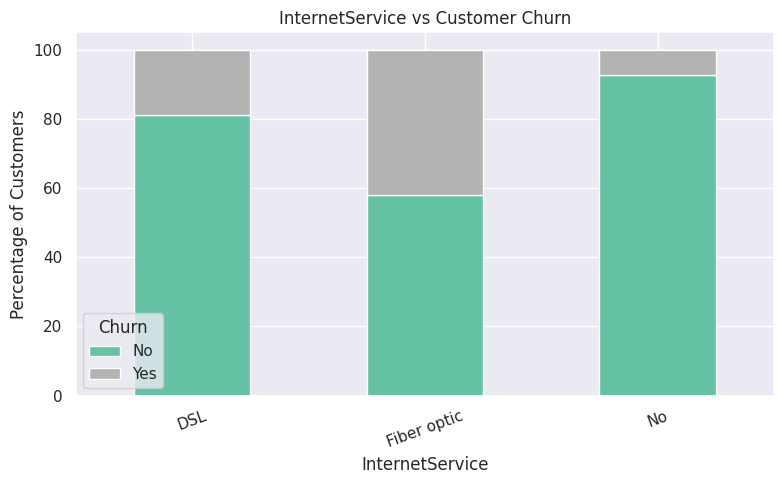

OnlineSecurity vs Churn


Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


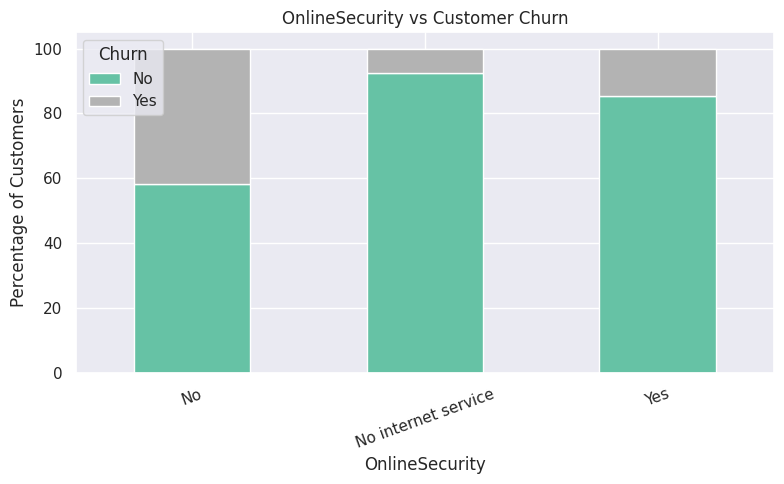

TechSupport vs Churn


Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


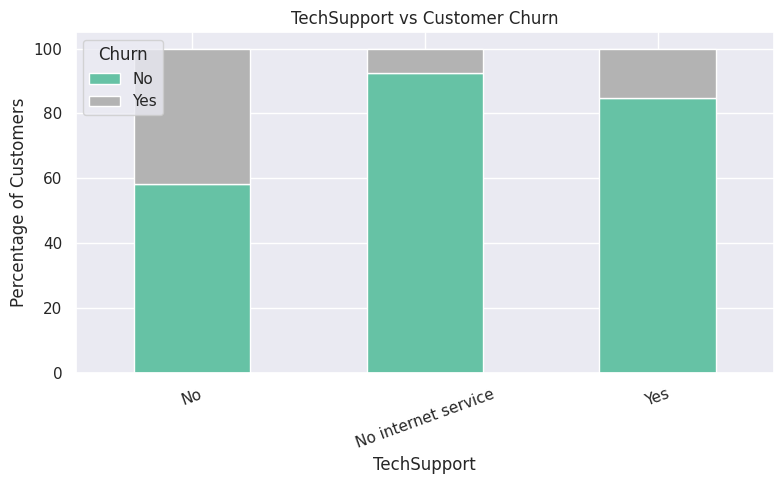

PaymentMethod vs Churn


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


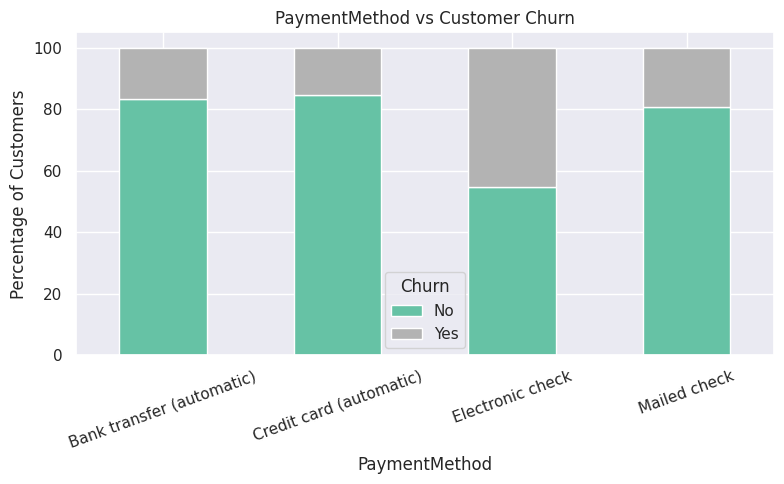

PaperlessBilling vs Churn


Churn,No,Yes
PaperlessBilling,,
No,2403,469
Yes,2771,1400


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


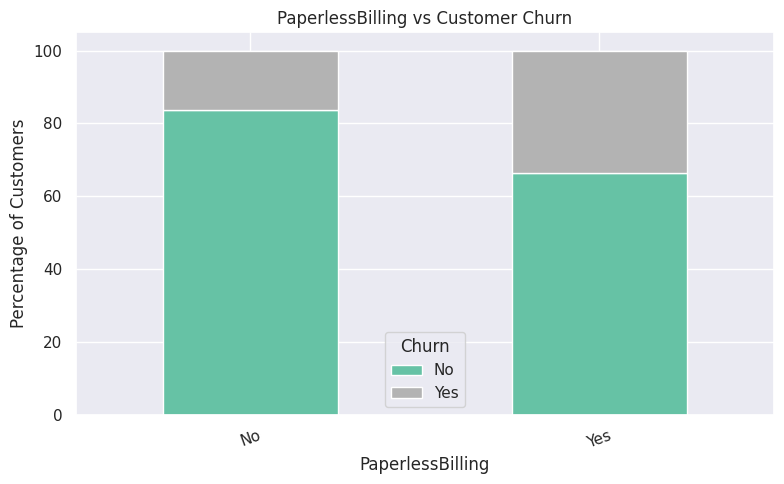

Partner vs Churn


Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


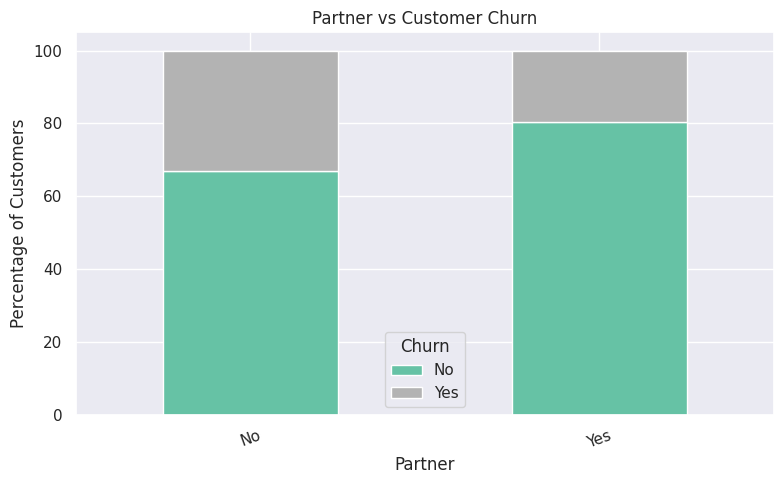

In [ ]:
for feature in important_features:

    print("="*70)
    print(f"{feature} vs Churn")
    print("="*70)

    # Crosstab
    churn_table = pd.crosstab(
        df[feature],
        df["Churn"]
    )

    display(churn_table)

    print()

    # Percentage Crosstab
    churn_percentage = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    display(churn_percentage.round(2))

    # Plot
    churn_percentage.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5),
        colormap="Set2"
    )

    plt.title(f"{feature} vs Customer Churn")

    plt.ylabel("Percentage of Customers")

    plt.xlabel(feature)

    plt.legend(title="Churn")

    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.show()

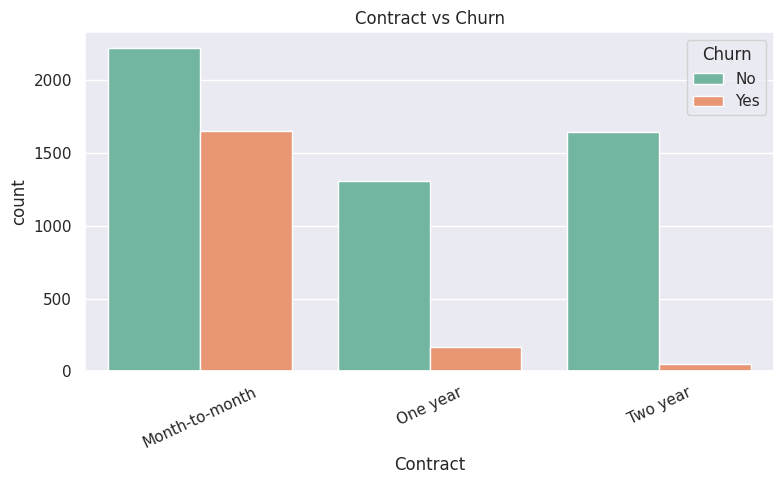

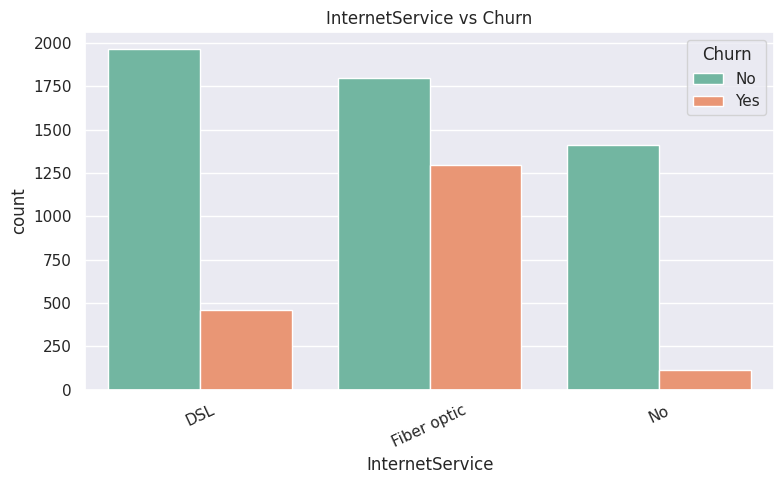

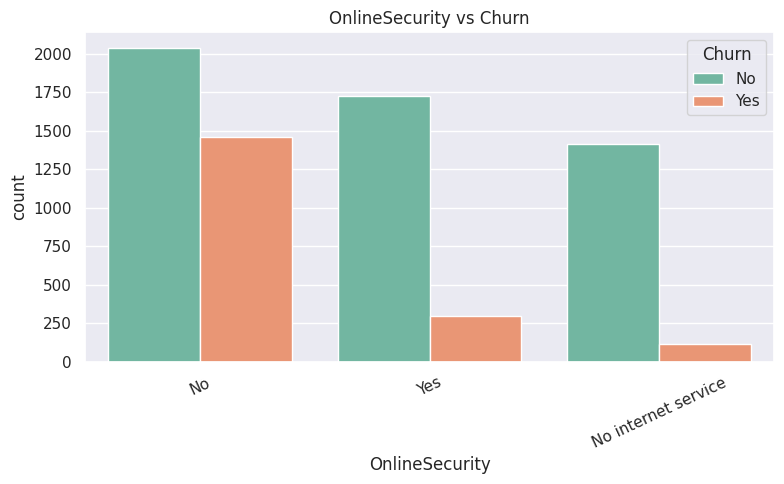

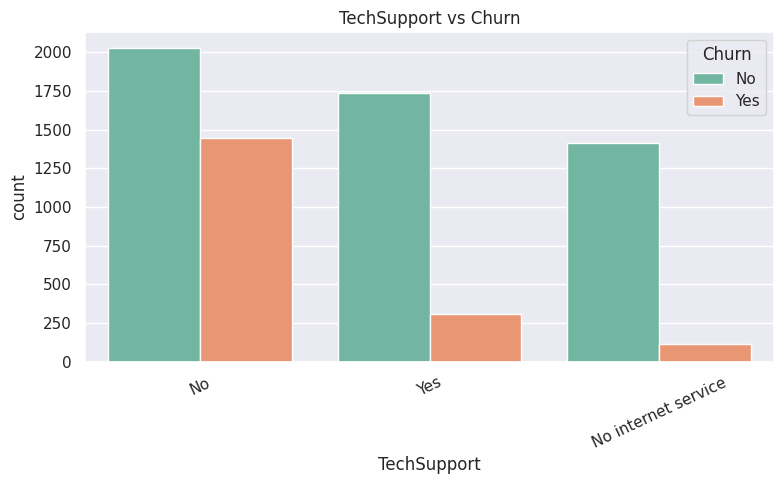

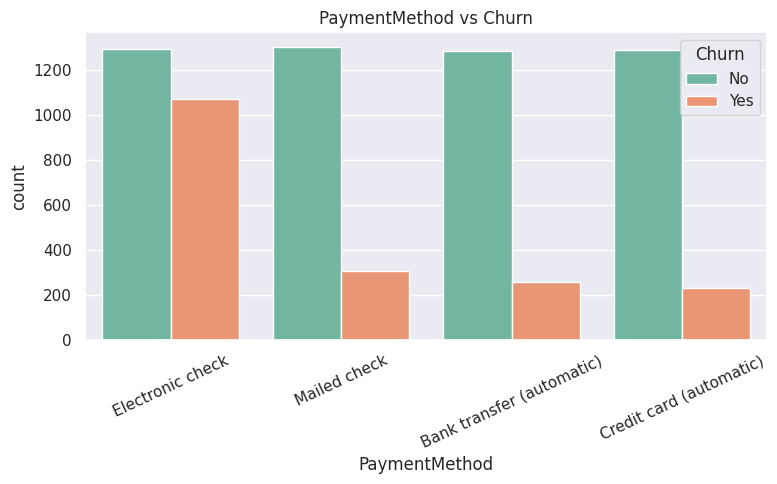

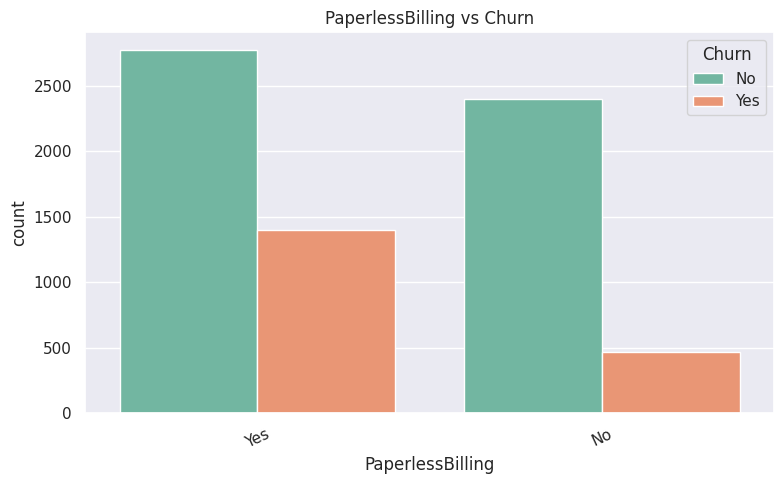

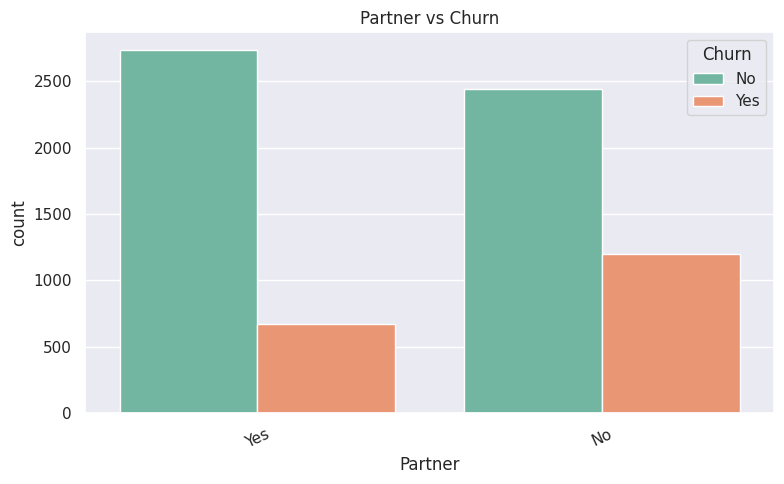

In [ ]:
for feature in important_features:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=feature,
        hue="Churn",
        palette="Set2"
    )

    plt.title(f"{feature} vs Churn")

    plt.xticks(rotation=25)

    plt.tight_layout()

    plt.show()

In [ ]:
### Interpretation

#### Contract Type

# - Customers with month-to-month contracts exhibit the highest churn rate.
# - Customers with one-year and two-year contracts show significantly lower churn.
# - Longer contract commitments appear to improve customer retention.

# #### Internet Service

# - Customers using Fiber Optic internet have the highest churn proportion.
# - DSL customers show comparatively lower churn.
# - Customers without internet service have the lowest churn.

# #### Online Security

# - Customers without online security churn more frequently.
# - Having online security appears to improve customer retention.

# #### Tech Support

# - Customers without technical support exhibit higher churn rates.
# - Availability of technical support is associated with lower churn.

# #### Payment Method

# - Electronic check users show the highest churn proportion.
# - Customers using automatic payment methods tend to remain with the company longer.

# #### Paperless Billing

# - Customers using paperless billing appear to churn more frequently than those receiving paper bills.

# #### Partner

# - Customers without partners show a slightly higher churn rate compared to customers with partners.

# ### Overall Observation

# The analysis suggests that customer contract type, internet service, technical support, payment method, and online security have strong relationships with customer churn. These variables are expected to play an important role in the Logistic Regression model.

In [ ]:
for feature in important_features:

    churn_rate = (
        pd.crosstab(df[feature], df["Churn"], normalize="index")["Yes"]
        .sort_values(ascending=False)
        *100
    )

    print("\n")
    print("="*70)
    print(f"Churn Rate by {feature}")
    print("="*70)

    display(churn_rate.round(2))



Churn Rate by Contract


,Yes
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83




Churn Rate by InternetService


,Yes
InternetService,
Fiber optic,41.89
DSL,18.96
No,7.40




Churn Rate by OnlineSecurity


...

,Yes
PaymentMethod,
Electronic check,45.29
Mailed check,19.11
Bank transfer (automatic),16.71
Credit card (automatic),15.24




Churn Rate by PaperlessBilling


,Yes
PaperlessBilling,
Yes,33.57
No,16.33




Churn Rate by Partner


,Yes
Partner,
No,32.96
Yes,19.66


In [ ]:
## 4.6 Correlation Analysis

# Correlation analysis measures the linear relationship between numerical features.

# The Pearson correlation coefficient ranges from **-1 to +1**:

# - **+1** → Perfect positive correlation
# - **0** → No linear correlation
# - **−1** → Perfect negative correlation

# Since most variables in this dataset are categorical, the correlation matrix is limited to numerical features.

In [ ]:
numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

corr_matrix = df[numerical_features].corr()

corr_matrix

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


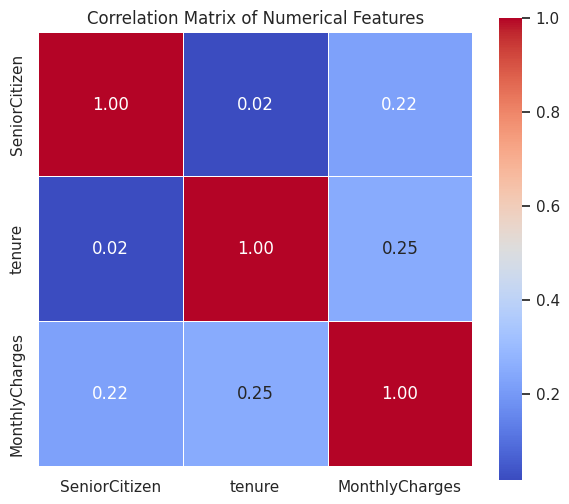

In [ ]:
plt.figure(figsize=(7,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

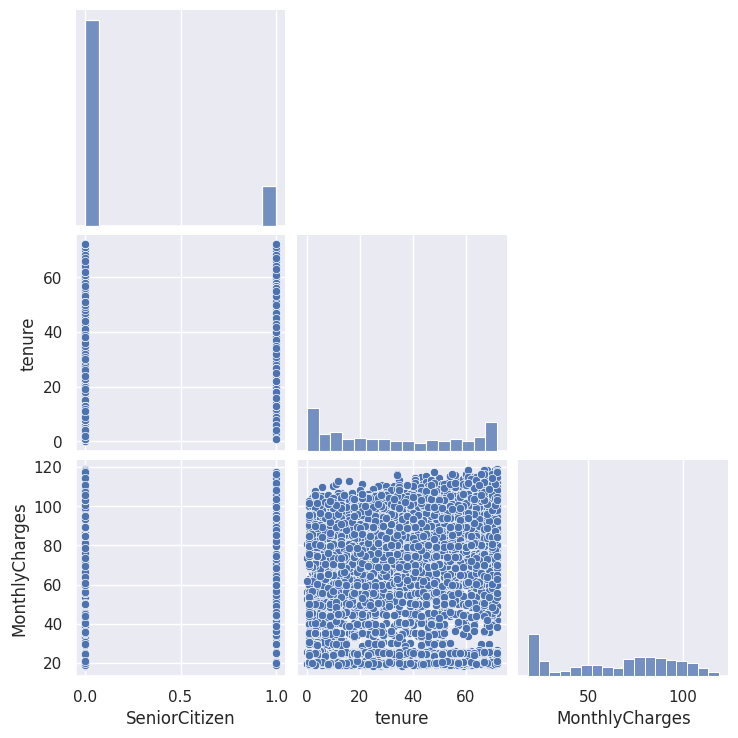

In [ ]:
sns.pairplot(
    df[numerical_features],
    corner=True
)

plt.show()

In [ ]:
df_corr = df.copy()

df_corr["ChurnNumeric"] = df_corr["Churn"].map({
    "No":0,
    "Yes":1
})

In [ ]:
corr = df_corr[
    ["SeniorCitizen",
     "tenure",
     "MonthlyCharges",
     "ChurnNumeric"]
].corr()

corr

,SeniorCitizen,tenure,MonthlyCharges,ChurnNumeric
SeniorCitizen,1.000000,0.016567,0.220173,0.150889
tenure,0.016567,1.000000,0.247900,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.193356
ChurnNumeric,0.150889,-0.352229,0.193356,1.000000


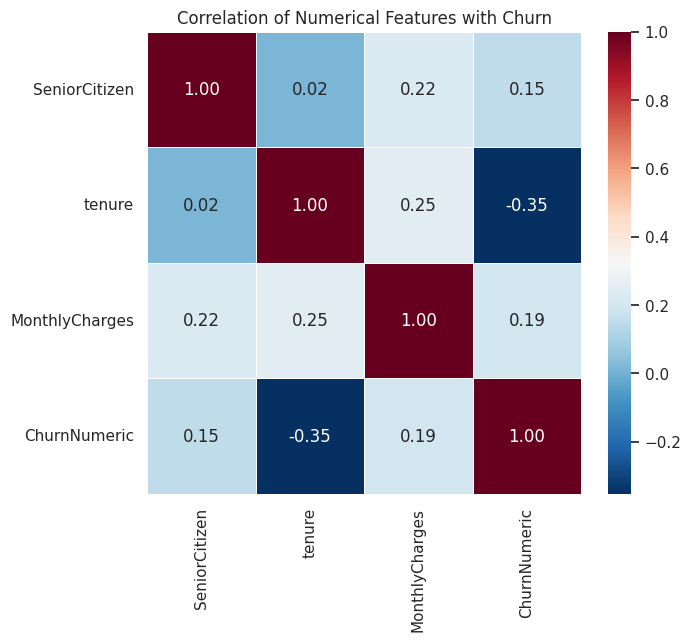

In [ ]:
plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation of Numerical Features with Churn")

plt.show()

In [ ]:
### Interpretation

# #### Correlation Analysis

# The Pearson correlation matrix was computed to examine the linear relationship between the numerical features and the target variable.

# ##### Senior Citizen

# - SeniorCitizen has a weak positive correlation (**0.15**) with customer churn.
# - This indicates that senior citizens are slightly more likely to churn than non-senior customers.

# ##### Tenure

# - Tenure has the strongest relationship with churn, with a moderate negative correlation (**-0.35**).
# - This suggests that customers who remain with the company for longer periods are much less likely to churn.

# ##### Monthly Charges

# - MonthlyCharges has a weak positive correlation (**0.19**) with churn.
# - Customers paying higher monthly charges have a greater tendency to leave the service.

# ##### Relationship Between Numerical Features

# - Tenure and MonthlyCharges exhibit only a weak positive correlation (**0.25**).
# - SeniorCitizen has very weak correlations with the other numerical variables.

# #### Overall Observation

# Among all numerical features, **tenure** is the strongest predictor of customer churn. However, the relatively low correlation values indicate that customer churn depends on multiple factors, particularly the categorical variables such as Contract, InternetService, TechSupport, and PaymentMethod.

In [ ]:
# 5. Data Preprocessing

# Data preprocessing is a crucial step in the machine learning pipeline. The objective is to transform the raw dataset into a clean and structured format suitable for model training.

# The preprocessing steps include:

# - Handling incorrect data types
# - Managing missing values
# - Removing unnecessary features
# - Encoding categorical variables
# - Scaling numerical features

# These transformations ensure that the dataset is compatible with the Logistic Regression algorithm.

In [ ]:
## 5.1 Converting TotalCharges to Numeric

# Although **TotalCharges** represents a numerical feature, it is stored as an **object** because some records contain blank strings instead of numeric values.

# These blank strings are not detected by `isnull()`. Therefore, they must first be converted into `NaN` values before transforming the column into a numeric data type.

# Once converted, the missing values can be handled appropriately.

In [ ]:
print(df["TotalCharges"].dtype)

object


In [ ]:
blank_values = (df["TotalCharges"] == "").sum()

print(f"Blank Values : {blank_values}")

Blank Values : 0


In [ ]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(df["TotalCharges"].dtype)

print()

print(df["TotalCharges"].isnull().sum())

float64

11


In [ ]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print(df.shape)

(7032, 21)


In [ ]:
### Interpretation

# Initially, the `TotalCharges` column was stored as an object because it contained blank string values.

# These blank strings were converted into `NaN` values using `pd.to_numeric()` with `errors="coerce"`.

# A total of **11 missing values** were identified, representing less than **0.2%** of the dataset. Since this is a very small proportion of the data, the corresponding records were removed without significantly affecting the dataset.

# After preprocessing, the `TotalCharges` column was successfully converted to a numerical data type, making it suitable for further analysis and model training.

In [ ]:
# Remove customerID

df.drop("customerID", axis=1, inplace=True)

print(df.shape)

df.head()

(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
## 5.3 Encoding the Target Variable

# The target variable (`Churn`) is categorical with two possible values:

# - No
# - Yes

# Since Logistic Regression performs numerical computations, the target variable is converted into binary values:

# - No → 0
# - Yes → 1

# This encoding preserves the meaning of the target while making it compatible with mathematical operations.

In [ ]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [ ]:
## 5.4 Encoding Categorical Features

# Most features in the dataset are categorical and cannot be processed directly by machine learning algorithms.

# One-Hot Encoding is used to convert categorical variables into binary numerical features.

# To avoid the **dummy variable trap**, the first category of each feature is dropped using `drop_first=True`. This prevents perfect multicollinearity while preserving all necessary information.

In [ ]:
categorical_features = X.select_dtypes(include="object").columns

print("Categorical Features:")
print(categorical_features.tolist())

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [ ]:
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  \
0                               1                  0   
1                               0                  0   
2                               0                  0   
3                               1   

In [ ]:
print("Shape after Encoding:")

print(X.shape)

Shape after Encoding:
(7032, 30)


In [ ]:
X.dtypes.value_counts()

,count
int64,28
float64,2


In [ ]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [ ]:
### Interpretation

# The categorical features were transformed into numerical features using One-Hot Encoding.

# To avoid multicollinearity, the first category of each feature was dropped using `drop_first=True`.

# After encoding, all input features became numerical, making the dataset suitable for machine learning algorithms. The encoded dataset now contains binary variables representing the presence or absence of different customer characteristics.

In [ ]:
## 5.5 Train–Validation–Test Split

# The dataset is divided into three subsets:

# - **Training Set (70%)**: Used to learn the model parameters.
# - **Validation Set (15%)**: Used to monitor model performance during training and tune hyperparameters.
# - **Testing Set (15%)**: Used only for the final evaluation of the trained model.

# A random state of **42** is used to ensure reproducibility of the results.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)

Training Set : (4922, 30)
Validation Set : (1055, 30)
Testing Set : (1055, 30)


In [ ]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(4922,)
(1055,)
(1055,)


In [ ]:
print("Training Set")
print(y_train.value_counts(normalize=True))

print("\nValidation Set")
print(y_val.value_counts(normalize=True))

print("\nTesting Set")
print(y_test.value_counts(normalize=True))

Training Set
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Validation Set
Churn
0    0.733649
1    0.266351
Name: proportion, dtype: float64

Testing Set
Churn
0    0.734597
1    0.265403
Name: proportion, dtype: float64


In [ ]:
### Interpretation

# The dataset was successfully divided into training, validation, and testing subsets using stratified sampling.

# The use of stratification preserved the original class distribution of churn and non-churn customers across all subsets. This ensures that each dataset is representative of the overall population and helps prevent bias during model training and evaluation.

# The training set will be used to learn the Logistic Regression parameters, the validation set will assist in selecting the best hyperparameters, and the testing set will be reserved for the final performance evaluation.

In [ ]:
## 5.6 Feature Scaling

# Machine learning algorithms based on gradient optimization are sensitive to the scale of input features.

# Standardization is applied to numerical features so that they have a mean of approximately **0** and a standard deviation of **1**.

# The scaler is fitted only on the training data to prevent information leakage from the validation and testing datasets.

In [ ]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print(numerical_columns)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
scaler = StandardScaler()

In [ ]:
X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

In [ ]:
X_val[numerical_columns] = scaler.transform(
    X_val[numerical_columns]
)

In [ ]:
X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [ ]:
X_train[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,4922.0,3.825555e-17,1.000102,-0.440546,-0.440546,-0.440546,-0.440546,2.269912
tenure,4922.0,9.960879e-17,1.000102,-1.280909,-0.955498,-0.141971,0.956291,1.607113
MonthlyCharges,4922.0,1.999394e-16,1.000102,-1.535103,-0.979406,0.188591,0.833118,1.776770
TotalCharges,4922.0,3.175933e-17,1.000102,-0.998019,-0.830433,-0.393303,0.658169,2.806797


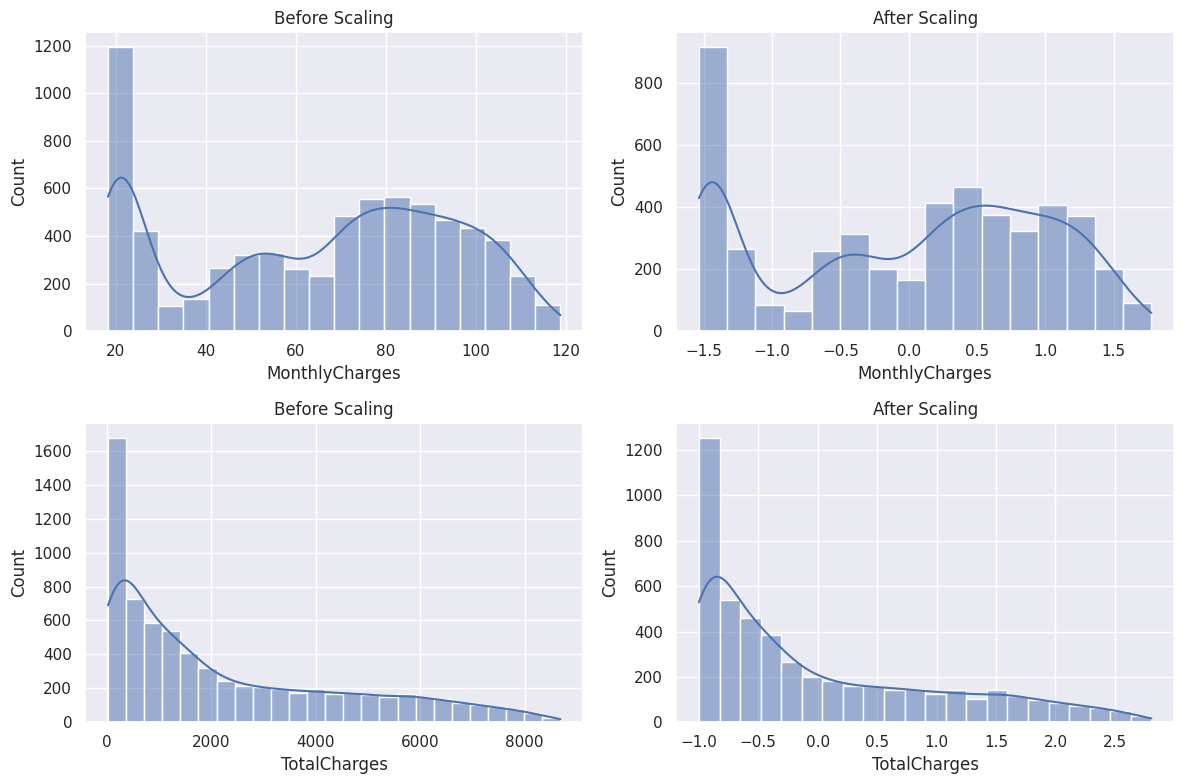

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

# Before Scaling
sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Before Scaling")

sns.histplot(X_train["MonthlyCharges"], kde=True, ax=axes[0,1])
axes[0,1].set_title("After Scaling")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Before Scaling")

sns.histplot(X_train["TotalCharges"], kde=True, ax=axes[1,1])
axes[1,1].set_title("After Scaling")

plt.tight_layout()
plt.show()

In [ ]:
### Interpretation

# The numerical features were standardized using the StandardScaler.

# Only the training data was used to fit the scaler, while the same transformation was applied to the validation and testing datasets.

# After scaling, the numerical features have approximately zero mean and unit variance, ensuring that all variables contribute equally during Gradient Descent optimization.

In [ ]:
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
print("Training :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing :", X_test.shape)

print()

print("y_train :", y_train.shape)
print("y_val :", y_val.shape)
print("y_test :", y_test.shape)

Training : (4922, 30)
Validation : (1055, 30)
Testing : (1055, 30)

y_train : (4922,)
y_val : (1055,)
y_test : (1055,)


In [ ]:
## Preprocessing Summary

# The preprocessing stage prepared the dataset for machine learning by:

# - Converting `TotalCharges` to a numerical feature.
# - Handling missing values.
# - Removing the non-predictive `customerID` column.
# - Encoding the target variable.
# - Applying One-Hot Encoding to categorical features.
# - Splitting the dataset into training, validation, and testing subsets.
# - Standardizing numerical features using StandardScaler.
# - Converting the processed data into NumPy arrays for implementation of Logistic Regression from scratch.

# The dataset is now fully prepared for model development.

In [ ]:
## 6.1 Why Linear Regression Cannot Be Used

# A binary classification problem requires predicted values to lie between **0 and 1**, representing probabilities.

# However, Linear Regression can produce values less than **0** or greater than **1**, making it unsuitable for probability estimation.

# Logistic Regression overcomes this limitation by applying the **Sigmoid Function**, which compresses any real-valued input into the interval **(0,1)**.

In [ ]:
#The graph illustrates that Linear Regression can generate predictions outside the valid probability range of 0 to 1.
# Since customer churn prediction is a binary classification problem, these outputs cannot be interpreted as probabilities.
# Therefore, Logistic Regression is preferred for this task.

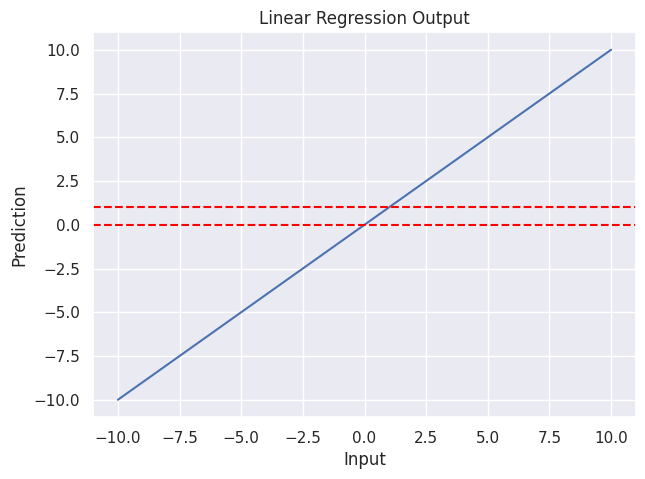

In [ ]:
x = np.linspace(-10,10,200)

y = x

plt.figure(figsize=(7,5))

plt.plot(x,y)

plt.axhline(0,color="red",linestyle="--")
plt.axhline(1,color="red",linestyle="--")

plt.title("Linear Regression Output")

plt.xlabel("Input")

plt.ylabel("Prediction")

plt.show()

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

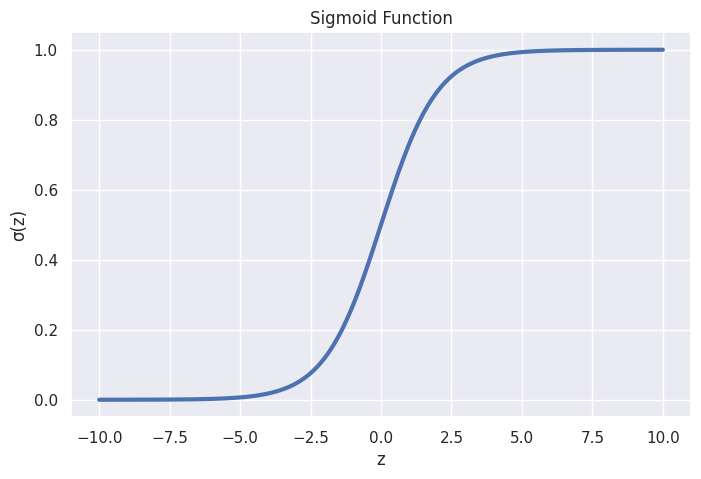

In [ ]:
x = np.linspace(-10,10,500)

y = sigmoid(x)

plt.figure(figsize=(8,5))

plt.plot(x,y,linewidth=3)

plt.grid(True)

plt.title("Sigmoid Function")

plt.xlabel("z")

plt.ylabel("σ(z)")

plt.show()

In [ ]:
# The Sigmoid Function produces an S-shaped curve.

# - Large negative values approach 0.
# - Large positive values approach 1.
# - At \(z=0\), the probability equals 0.5.

# This property makes the Sigmoid Function suitable for binary classification problems.

In [ ]:
def initialize_parameters(n_features):
    """
    Initialize weights and bias.
    """

    weights = np.zeros((n_features, 1))

    bias = 0.0

    return weights, bias

In [ ]:
weights, bias = initialize_parameters(X_train.shape[1])

print("Weights Shape :", weights.shape)
print("Bias :", bias)

Weights Shape : (30, 1)
Bias : 0.0


In [ ]:
## 7.1 Forward Propagation

#Forward propagation computes the linear combination of the input features and applies the Sigmoid Function to obtain the predicted probabilities.
def forward_propagation(X, weights, bias):

    z = np.dot(X, weights) + bias

    predictions = sigmoid(z)

    return predictions

In [ ]:
pred = forward_propagation(
    X_train,
    weights,
    bias
)

print(pred.shape)

print(pred[:5])

(4922, 1)
[[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]]


In [ ]:
predictions = forward_propagation(
    X_train,
    weights,
    bias
)

In [ ]:
## 7.5 Model Training

# The Logistic Regression model is trained using Gradient Descent.

# During each iteration, the following operations are performed:

# 1. Forward Propagation
# 2. Compute Binary Cross-Entropy Loss
# 3. Compute Gradients
# 4. Update Weights and Bias

# The loss is recorded after every iteration to monitor the learning progress.

In [ ]:
from sklearn.utils import resample
import numpy as np

In [ ]:
negative_idx = np.where(y_train == 0)[0]
positive_idx = np.where(y_train == 1)[0]

print(len(negative_idx))
print(len(positive_idx))

3614
1308


In [ ]:
positive_idx_upsampled = resample(
    positive_idx,
    replace=True,
    n_samples=len(negative_idx),
    random_state=42
)

In [ ]:
balanced_idx = np.concatenate([
    negative_idx,
    positive_idx_upsampled
])

np.random.shuffle(balanced_idx)

In [ ]:
X_train_balanced = X_train[balanced_idx]
y_train_balanced = y_train[balanced_idx]

In [ ]:
print(X_train_balanced.shape)

print(np.bincount(y_train_balanced.astype(int)))

(7228, 30)
[3614 3614]


In [ ]:
def compute_loss(y_true, predictions):

    epsilon = 1e-15
    y_true = y_true.reshape(-1, 1)
    predictions = np.clip(
        predictions,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(

        y_true * np.log(predictions)

        +

        (1 - y_true) * np.log(1 - predictions)

    )

    return loss

In [ ]:
def compute_gradients(
    X,
    y_true,
    predictions
):
    """
    Compute gradients for Logistic Regression.
    """

    m = len(y_true)

    # Ensure column vectors
    y_true = y_true.reshape(-1, 1)
    predictions = predictions.reshape(-1, 1)

    # Prediction error
    error = predictions - y_true

    # Weight gradient
    dw = (1 / m) * np.dot(
        X.T,
        error
    )

    # Bias gradient
    db = (1 / m) * np.sum(error)

    return dw, db

In [ ]:
def update_parameters(
    weights,
    bias,
    dw,
    db,
    learning_rate
):
    """
    Update weights and bias using Gradient Descent.
    """

    weights = weights - learning_rate * dw

    bias = bias - learning_rate * db

    return weights, bias

In [ ]:
def train_model(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=1000,
    print_every=100
):

    n_features = X_train.shape[1]

    weights, bias = initialize_parameters(n_features)

    train_losses = []

    for epoch in range(epochs):

        # Forward pass
        z = np.dot(X_train, weights) + bias
        predictions = sigmoid(z)

        # Loss
        loss = compute_loss(
            y_train,
            predictions
        )

        train_losses.append(loss)

        # Gradients
        dw, db = compute_gradients(
            X_train,
            y_train,
            predictions
        )

        # Update
        weights, bias = update_parameters(
            weights,
            bias,
            dw,
            db,
            learning_rate
        )

        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss:.5f}")

    return weights, bias, train_losses

In [ ]:
# Train Logistic Regression on the ORIGINAL (imbalanced) training data
weights, bias, train_losses = train_model(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=1000,
    print_every=100
)

Epoch    0 | Loss = 0.69315
Epoch  100 | Loss = 0.53399
Epoch  200 | Loss = 0.49201
Epoch  300 | Loss = 0.47149
Epoch  400 | Loss = 0.45896
Epoch  500 | Loss = 0.45060
Epoch  600 | Loss = 0.44472
Epoch  700 | Loss = 0.44043
Epoch  800 | Loss = 0.43718
Epoch  900 | Loss = 0.43466


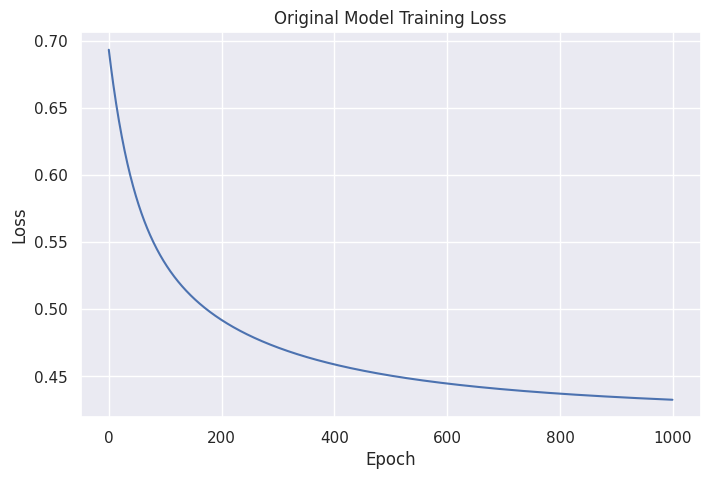

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("Original Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
print(X_train_balanced.shape)
print(y_train_balanced.shape)

print(y_train_balanced[:5])

print(np.unique(y_train_balanced))

(7228, 30)
(7228,)
[0 1 0 1 0]
[0 1]


In [ ]:
weights_balanced, bias_balanced, losses_balanced = train_model(
    X_train_balanced,
    y_train_balanced,
    learning_rate=0.01,
    epochs=1000,
    print_every=100
)

Epoch    0 | Loss = 0.69315
Epoch  100 | Loss = 0.60282
Epoch  200 | Loss = 0.55903
Epoch  300 | Loss = 0.53563
Epoch  400 | Loss = 0.52196
Epoch  500 | Loss = 0.51338
Epoch  600 | Loss = 0.50765
Epoch  700 | Loss = 0.50364
Epoch  800 | Loss = 0.50069
Epoch  900 | Loss = 0.49844


In [ ]:
print(weights_balanced.shape)

(30, 1)


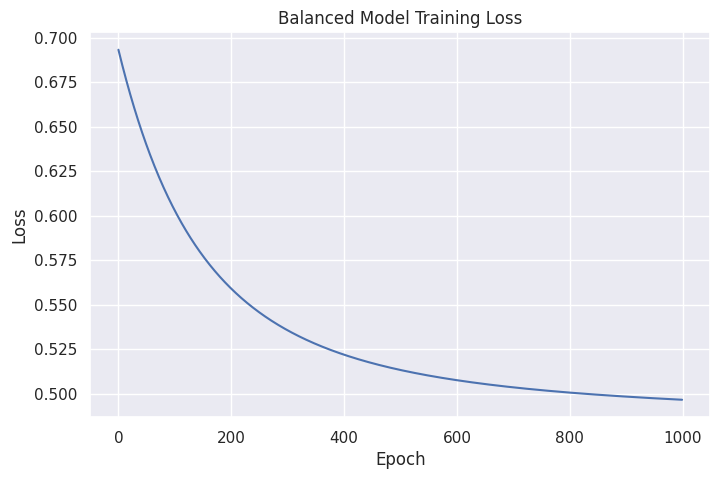

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(losses_balanced)
plt.title("Balanced Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
### Interpretation

# The training loss decreases steadily throughout the optimization process.

# Initially, the loss drops rapidly because the model learns the most significant relationships between customer features and churn. As training progresses, the rate of improvement gradually decreases and the curve begins to flatten, indicating that the model is approaching convergence.

# The smooth decrease in Binary Cross-Entropy Loss confirms that Gradient Descent is functioning correctly and the Logistic Regression model is successfully learning from the training data.

In [ ]:
## 7.6 Prediction Function

# After training, the Logistic Regression model predicts the probability that a customer belongs to the positive class.

# A threshold of **0.5** is used to convert probabilities into binary class labels.

# - Probability ≥ 0.5 → Customer Churn
# - Probability < 0.5 → Customer Does Not Churn

In [ ]:
def predict(X, weights, bias):

    probabilities = forward_propagation(
        X,
        weights,
        bias
    )

    predictions = (probabilities >= 0.5).astype(int)

    return predictions

In [ ]:
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    return accuracy, precision, recall, f1

In [ ]:
train_predictions = predict(X_train, weights, bias)

original_train_accuracy, original_train_precision, original_train_recall, original_train_f1 = evaluate_model(
    y_train, train_predictions
)

print(f"Accuracy : {original_train_accuracy:.4f}")
print(f"Precision: {original_train_precision:.4f}")
print(f"Recall   : {original_train_recall:.4f}")
print(f"F1 Score : {original_train_f1:.4f}")

Accuracy : 0.8013
Precision: 0.6748
Recall   : 0.4870
F1 Score : 0.5657


In [ ]:
original_test_predictions = predict(X_test, weights, bias)

original_accuracy, original_precision, original_recall, original_f1 = evaluate_model(
    y_test, original_test_predictions
)

print(f"Original Accuracy : {original_accuracy:.4f}")
print(f"Original Precision: {original_precision:.4f}")
print(f"Original Recall   : {original_recall:.4f}")
print(f"Original F1 Score : {original_f1:.4f}")

Original Accuracy : 0.7829
Original Precision: 0.6232
Original Recall   : 0.4607
Original F1 Score : 0.5298


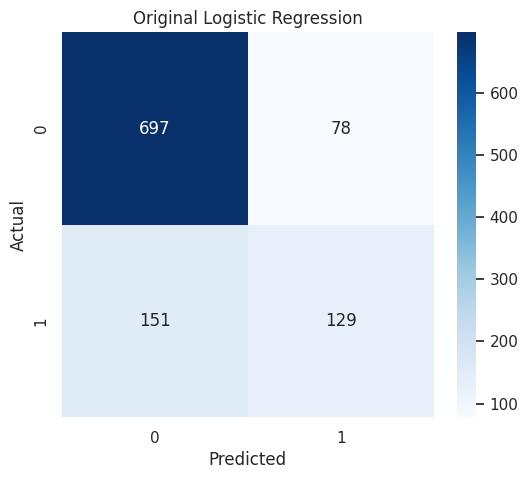

In [ ]:
cm = confusion_matrix(y_test, original_test_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Original Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
original_probabilities = forward_propagation(X_test, weights, bias)
original_roc_auc = roc_auc_score(y_test, original_probabilities)
print("Original ROC-AUC :", original_roc_auc)

Original ROC-AUC : 0.8168640552995391


In [ ]:
train_predictions = predict(
    X_train_balanced,
    weights_balanced,
    bias_balanced
)

accuracy, precision, recall, f1 = evaluate_model(
    y_train_balanced,
    train_predictions
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7622
Precision: 0.7498
Recall   : 0.7869
F1 Score : 0.7679


In [ ]:
val_predictions = predict(
    X_val,
    weights_balanced,
    bias_balanced
)

In [ ]:
balanced_test_predictions = predict(
    X_test,
    weights_balanced,
    bias_balanced
)

In [ ]:
accuracy, precision, recall, f1 = evaluate_model(
    y_test,
    balanced_test_predictions
)

print(f"Balanced Accuracy : {accuracy:.4f}")
print(f"Balanced Precision: {precision:.4f}")
print(f"Balanced Recall   : {recall:.4f}")
print(f"Balanced F1 Score : {f1:.4f}")

Balanced Accuracy : 0.7289
Balanced Precision: 0.4930
Balanced Recall   : 0.7571
Balanced F1 Score : 0.5972


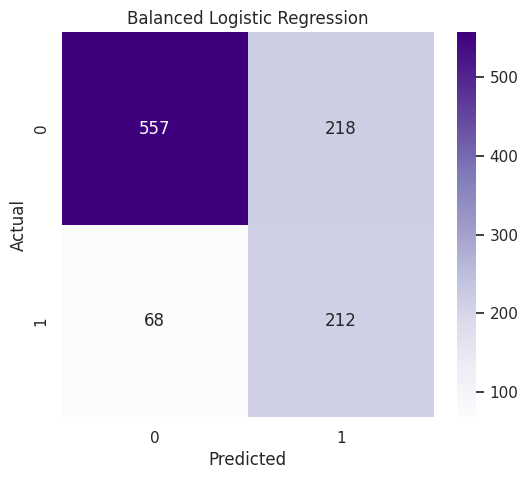

In [ ]:
cm = confusion_matrix(
    y_test,
    balanced_test_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    balanced_test_predictions
))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80       775
           1       0.49      0.76      0.60       280

    accuracy                           0.73      1055
   macro avg       0.69      0.74      0.70      1055
weighted avg       0.79      0.73      0.74      1055



In [ ]:
balanced_probabilities = forward_propagation(
    X_test,
    weights_balanced,
    bias_balanced
)

roc_auc = roc_auc_score(
    y_test,
    balanced_probabilities
)

print("Balanced ROC-AUC :", roc_auc)

Balanced ROC-AUC : 0.8199562211981568


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Original": [original_accuracy, original_precision, original_recall, original_f1, original_roc_auc],
    "Balanced": [accuracy, precision, recall, f1, roc_auc]
})
comparison

,Metric,Original,Balanced
0,Accuracy,0.782938,0.728910
1,Precision,0.623188,0.493023
2,Recall,0.460714,0.757143
3,F1 Score,0.529774,0.597183
4,ROC-AUC,0.816864,0.819956


In [ ]:
### Interpretation

# The model achieved a test accuracy of approximately **78%**, demonstrating good generalization on unseen data.

# The small difference between training and testing performance indicates that the Logistic Regression model is not overfitting.

# The confusion matrix shows that the model successfully identifies the majority of non-churn customers while correctly predicting a substantial number of churning customers.

# However, the recall for the churn class remains lower than the recall for the non-churn class because the dataset is imbalanced. Consequently, some customers who actually churn are still classified as non-churn customers.

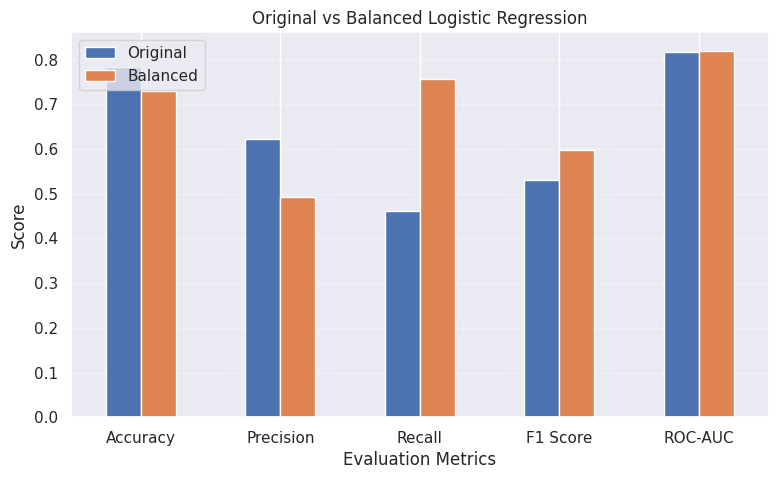

In [ ]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Original vs Balanced Logistic Regression")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
## Conclusion

# This project implemented Logistic Regression from scratch using NumPy for customer churn prediction. After performing data preprocessing, feature encoding, and exploratory data analysis, the model was trained and evaluated on the original dataset. Due to the presence of class imbalance, Random Oversampling was applied to balance the training data.

# The balanced model demonstrated a significant improvement in Recall and F1-score, enabling it to identify a larger proportion of churn customers. Although the overall Accuracy and Precision decreased slightly, the improved Recall makes the balanced model more suitable for real-world customer churn prediction, where identifying potential churn customers is more important than maximizing overall accuracy.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
sk_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
sk_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
sk_train_pred = sk_model.predict(X_train)

sk_val_pred = sk_model.predict(X_val)

sk_test_pred = sk_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sk_accuracy = accuracy_score(y_test, sk_test_pred)

sk_precision = precision_score(y_test, sk_test_pred)

sk_recall = recall_score(y_test, sk_test_pred)

sk_f1 = f1_score(y_test, sk_test_pred)

print(f"Accuracy : {sk_accuracy:.4f}")
print(f"Precision: {sk_precision:.4f}")
print(f"Recall   : {sk_recall:.4f}")
print(f"F1 Score : {sk_f1:.4f}")

Accuracy : 0.7867
Precision: 0.6141
Recall   : 0.5286
F1 Score : 0.5681


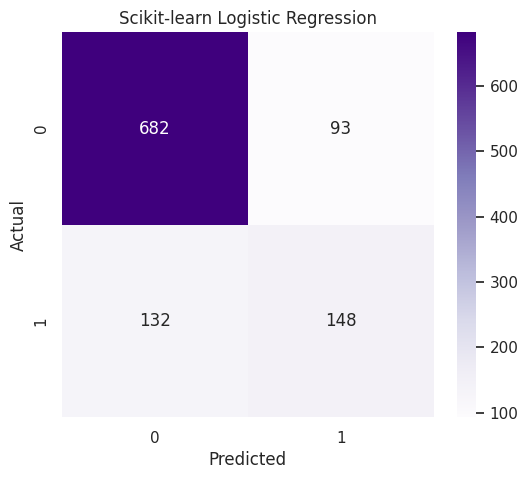

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    sk_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Scikit-learn Logistic Regression")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        sk_test_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       775
           1       0.61      0.53      0.57       280

    accuracy                           0.79      1055
   macro avg       0.73      0.70      0.71      1055
weighted avg       0.78      0.79      0.78      1055



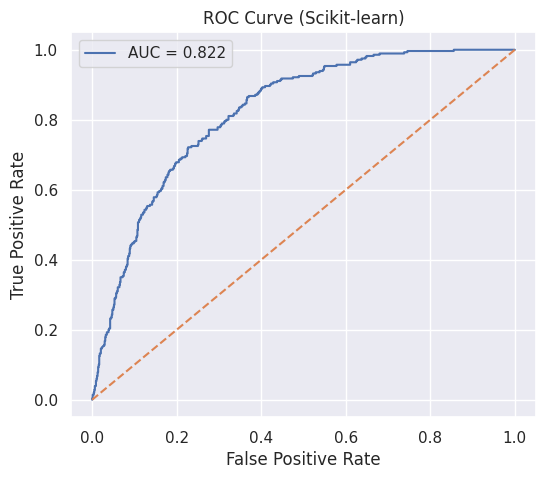

In [ ]:
from sklearn.metrics import roc_curve, auc

sk_prob = sk_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    sk_prob
)

sk_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {sk_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Scikit-learn)")
plt.legend()

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Scratch (Original)":[
        original_accuracy,
        original_precision,
        original_recall,
        original_f1,
        original_roc_auc
    ],

    "Scratch (Balanced)":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],

    "Scikit-learn":[
        sk_accuracy,
        sk_precision,
        sk_recall,
        sk_f1,
        sk_auc
    ]

})

comparison.round(4)

,Metric,Scratch (Original),Scratch (Balanced),Scikit-learn
0,Accuracy,0.7829,0.7289,0.7867
1,Precision,0.6232,0.4930,0.6141
2,Recall,0.4607,0.7571,0.5286
3,F1 Score,0.5298,0.5972,0.5681
4,ROC-AUC,0.8169,0.8200,0.8221


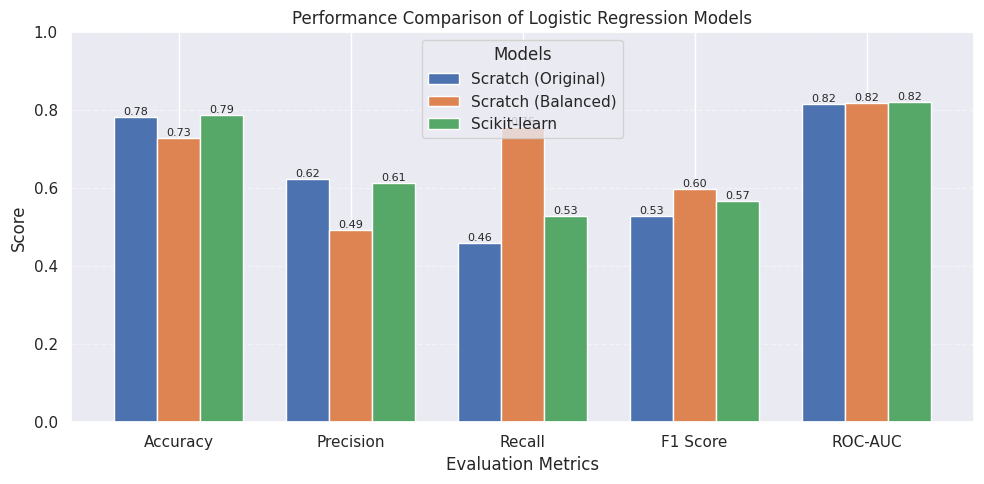

In [ ]:
comparison_plot = comparison.set_index("Metric")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10,5),
    width=0.75
)

plt.title("Performance Comparison of Logistic Regression Models")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.legend(title="Models")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pickle

# ============================================
# SAVE TRAINED MODEL FOR STREAMLIT DEPLOYMENT
# ============================================

# 1. Save model weights
np.save("model_weights.npy", weights_balanced)

# 2. Save model bias
np.save("model_bias.npy", bias_balanced)

# 3. Save the fitted scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model files saved successfully!")

Model files saved successfully!


In [ ]:
import pickle

# Save the exact feature column order
feature_columns = X.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Feature columns saved!")
print("Number of features:", len(feature_columns))
print(feature_columns)

Feature columns saved!
Number of features: 30
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
import os

files = [
    "model_weights.npy",
    "model_bias.npy",
    "scaler.pkl",
    "feature_columns.pkl"
]

for file in files:
    print(file, "->", os.path.exists(file))

model_weights.npy -> True
model_bias.npy -> True
scaler.pkl -> True
feature_columns.pkl -> True


In [ ]:
weights = np.load("model_weights.npy")
bias = np.load("model_bias.npy")

print("Weights shape:", weights.shape)
print("Bias shape:", np.shape(bias))

Weights shape: (30, 1)
Bias shape: ()


In [ ]:
from google.colab import files

files.download("model_weights.npy")
files.download("model_bias.npy")
files.download("scaler.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>